# Project Report

## Student Details

- **Name:** Nitish Kumar Bind
- **Roll No:** 253000112
- **Branch:** M.Tech (CSE)
- **Subject:** Decision Science in AI


**Project 1: Autonomous Ocean Submersible Exploration System**

Problem Statement: An underwater research submersible plans a traversal across a seabed grid to reach a hydrothermal vent for sampling using MDP, and learns improved strategies over time under ocean-current drift uncertainty using RL.

Tasks:
\
DP for task optimisation\
MDP for decision making\
RL for learning unknown patterns

=== DP Shortest Path ===
[[ 6.  5.  4.  3.]
 [ 5.  4. inf  2.]
 [ 4.  3.  2.  1.]
 [ 3.  2.  1.  0.]]

=== MDP Value Iteration ===
[[-0.62406142  0.34873275  1.59106686  3.20093725]
 [ 0.556553    1.75236425  0.          5.23563456]
 [ 1.87326451  3.53411347  5.44491525  7.35169492]
 [ 3.09570047  5.06735225  7.35169492 10.        ]]

=== RL Q-Learning ===


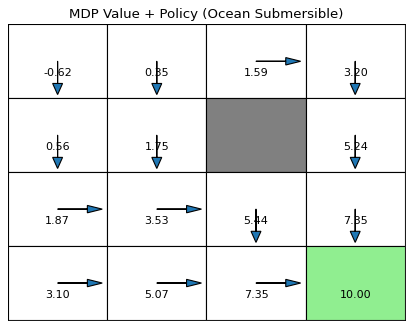

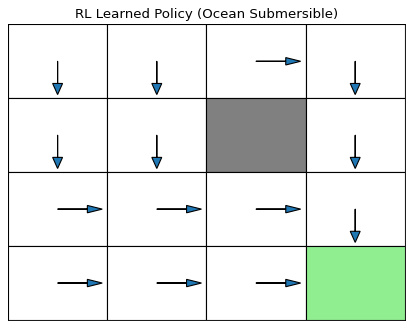

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt


# ================================
# ENVIRONMENT SETUP
# ================================

GRID_SIZE = (4, 4)
GOAL = (3, 3)
OBSTACLES = [(1, 2)]
ACTIONS = ['up', 'down', 'left', 'right']

GAMMA = 0.9
STEP_REWARD = -1
GOAL_REWARD = 10


def is_valid(state):
    x, y = state
    return 0 <= x < GRID_SIZE[0] and 0 <= y < GRID_SIZE[1] and state not in OBSTACLES


def move(state, action):
    x, y = state
    if action == 'up': new = (x-1, y)
    elif action == 'down': new = (x+1, y)
    elif action == 'left': new = (x, y-1)
    elif action == 'right': new = (x, y+1)
    return new if is_valid(new) else state


# ================================
# TRANSITION MODEL (ocean current drift)
# ================================

def get_transitions(action):
    if action == 'up':
        return [(0.8, 'up'), (0.1, 'left'), (0.1, 'right')]
    if action == 'down':
        return [(0.8, 'down'), (0.1, 'left'), (0.1, 'right')]
    if action == 'left':
        return [(0.8, 'left'), (0.1, 'up'), (0.1, 'down')]
    if action == 'right':
        return [(0.8, 'right'), (0.1, 'up'), (0.1, 'down')]


# ================================
# 1. DP: SHORTEST PATH
# ================================

def dp_shortest_path():
    cost = np.full(GRID_SIZE, np.inf)
    cost[GOAL] = 0

    for _ in range(50):
        for x in range(GRID_SIZE[0]):
            for y in range(GRID_SIZE[1]):
                if (x, y) in OBSTACLES:
                    continue
                for a in ACTIONS:
                    nx, ny = move((x, y), a)
                    cost[x, y] = min(cost[x, y], cost[nx, ny] + 1)

    return cost


# ================================
# 2. MDP: VALUE ITERATION
# ================================

def value_iteration():
    U = np.zeros(GRID_SIZE)

    for _ in range(100):
        new_U = U.copy()

        for x in range(GRID_SIZE[0]):
            for y in range(GRID_SIZE[1]):
                if (x, y) in OBSTACLES:
                    continue

                if (x, y) == GOAL:
                    new_U[x, y] = GOAL_REWARD
                    continue

                action_values = []

                for a in ACTIONS:
                    total = 0
                    for p, act in get_transitions(a):
                        nx, ny = move((x, y), act)
                        total += p * U[nx, ny]

                    action_values.append(total)

                new_U[x, y] = STEP_REWARD + GAMMA * max(action_values)

        U = new_U

    return U


# ================================
# 3. RL: Q-LEARNING
# ================================

def q_learning(episodes=500):
    Q = {}

    def get_Q(s, a):
        return Q.get((s, a), 0.0)

    for _ in range(episodes):
        state = (0, 0)

        while state != GOAL:
            if random.random() < 0.2:
                action = random.choice(ACTIONS)
            else:
                action = max(ACTIONS, key=lambda a: get_Q(state, a))

            next_state = move(state, action)
            reward = GOAL_REWARD if next_state == GOAL else STEP_REWARD

            best_next = max([get_Q(next_state, a) for a in ACTIONS])

            Q[(state, action)] = get_Q(state, action) + 0.1 * (
                reward + GAMMA * best_next - get_Q(state, action)
            )

            state = next_state

    return Q


# ================================
# POLICY EXTRACTION
# ================================

def extract_policy(U):
    policy = {}

    for x in range(GRID_SIZE[0]):
        for y in range(GRID_SIZE[1]):
            if (x, y) in OBSTACLES or (x, y) == GOAL:
                continue

            best_action = None
            best_value = -float('inf')

            for a in ACTIONS:
                nx, ny = move((x, y), a)
                if U[nx, ny] > best_value:
                    best_value = U[nx, ny]
                    best_action = a

            policy[(x, y)] = best_action

    return policy


def extract_policy_from_Q(Q):
    policy = {}

    for x in range(GRID_SIZE[0]):
        for y in range(GRID_SIZE[1]):
            state = (x, y)
            if state in OBSTACLES or state == GOAL:
                continue

            best_action = max(ACTIONS, key=lambda a: Q.get((state, a), 0))
            policy[state] = best_action

    return policy


# ================================
# VISUALIZATION
# ================================

def plot_grid(U=None, policy=None, title="Grid World"):
    fig, ax = plt.subplots()

    for x in range(GRID_SIZE[0]):
        for y in range(GRID_SIZE[1]):
            rect = plt.Rectangle((y, GRID_SIZE[0]-x-1), 1, 1,
                                 edgecolor='black', facecolor='white')
            ax.add_patch(rect)

            if (x, y) in OBSTACLES:
                rect.set_facecolor('gray')

            if (x, y) == GOAL:
                rect.set_facecolor('lightgreen')

            if U is not None and (x, y) not in OBSTACLES:
                ax.text(y+0.5, GRID_SIZE[0]-x-0.7,
                        f"{U[x,y]:.2f}", ha='center')

            if policy is not None and (x, y) in policy:
                dx, dy = 0, 0
                if policy[(x, y)] == 'up': dy = 0.3
                elif policy[(x, y)] == 'down': dy = -0.3
                elif policy[(x, y)] == 'left': dx = -0.3
                elif policy[(x, y)] == 'right': dx = 0.3

                ax.arrow(y+0.5, GRID_SIZE[0]-x-0.5,
                         dx, dy, head_width=0.1)

    ax.set_xlim(0, GRID_SIZE[1])
    ax.set_ylim(0, GRID_SIZE[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()


if __name__ == "__main__":

    print("=== DP Shortest Path ===")
    print(dp_shortest_path())

    print("\n=== MDP Value Iteration ===")
    U = value_iteration()
    print(U)

    policy = extract_policy(U)
    plot_grid(U, policy, title="MDP Value + Policy (Ocean Submersible)")

    print("\n=== RL Q-Learning ===")
    Q = q_learning()
    rl_policy = extract_policy_from_Q(Q)

    plot_grid(policy=rl_policy, title="RL Learned Policy (Ocean Submersible)")

## Results and Analysis
### DP vs MDP vs RL

| Method | Knowledge Required | Handles Uncertainty | Learning Ability |
| :--- | :--- | :--- | :--- |
| DP | Full | No | No |
| MDP | Full | Yes | No |
| RL | None | Yes | Yes |


##Key Observations
DP finds the shortest traversal path but ignores ocean-current drift
MDP produces safer and optimal traversal policies for the submersible
RL learns optimal navigation behaviour over time
With 500 episodes, RL nearly converges to MDP policy
6. Visualization

Two visualizations were generated:

1. MDP Value + Policy
Shows state values and optimal traversal actions
Submersible prefers safe and efficient paths toward the hydrothermal vent
2. RL Learned Policy
Shows learned actions after training
Closely matches MDP policy
##Conclusion

This project demonstrates how different techniques contribute to intelligent submersible decision-making:

DP provides baseline route optimization
MDP handles ocean-current and sensor uncertainty in navigation decisions
RL enables the submersible to learn from experience

The results confirm that:

Reinforcement Learning converges to the optimal policy defined by MDP as training increases.

## Project 2: Smart Irrigation Scheduling for Precision Agriculture
###Problem Statement: A precision-agriculture controller selects the right irrigation intensity for each soil-moisture state to maximise long-term crop yield while avoiding water waste and root damage.
Tasks:\
DP for short-term optimisation\
MDP formulation of irrigation scheduling\
RL for crop-response learning

=== DP Solution ===
Policy: {'Dry': 'Heavy', 'Moderate': 'Light', 'Wet': 'Light'}
Values: {'Dry': 135.0, 'Moderate': 90.0, 'Wet': 60.0}

=== MDP Solution ===
Utilities: {'Dry': 998.2571931671002, 'Moderate': 913.4456632336193, 'Wet': 861.893556803464}
Policy: {'Dry': 'Heavy', 'Moderate': 'Light', 'Wet': 'Light'}

=== RL Solution ===
Policy: {'Dry': 'Heavy', 'Moderate': 'Light', 'Wet': 'Light'}


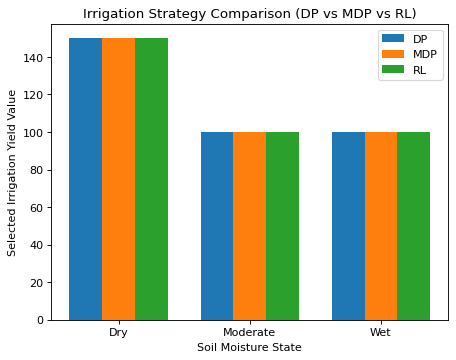

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt


# ================================
# SETUP
# ================================

states = ['Dry', 'Moderate', 'Wet']         # Soil moisture levels
actions = ['None', 'Light', 'Heavy']        # Irrigation intensity

yield_value = {
    'None': 50,
    'Light': 100,
    'Heavy': 150
}

# Probability of healthy crop growth under each irrigation action given soil state
success_prob = {
    'Dry':      {'None': 0.1, 'Light': 0.5, 'Heavy': 0.9},
    'Moderate': {'None': 0.4, 'Light': 0.9, 'Heavy': 0.6},
    'Wet':      {'None': 0.8, 'Light': 0.6, 'Heavy': 0.3}
}

# Transition probabilities between soil moisture states (weather / evaporation)
transitions = {
    'Dry':      {'Dry': 0.6, 'Moderate': 0.3, 'Wet': 0.1},
    'Moderate': {'Dry': 0.2, 'Moderate': 0.5, 'Wet': 0.3},
    'Wet':      {'Dry': 0.1, 'Moderate': 0.3, 'Wet': 0.6}
}

GAMMA = 0.9


def reward(state, action):
    value = yield_value[action]
    prob = success_prob[state][action]
    return value * prob


def dp_solution():
    dp_policy = {}
    dp_values = {}

    for s in states:
        best_val = -1
        best_action = None

        for a in actions:
            r = reward(s, a)
            if r > best_val:
                best_val = r
                best_action = a

        dp_policy[s] = best_action
        dp_values[s] = best_val

    return dp_policy, dp_values


def value_iteration():
    U = {s: 0 for s in states}

    for _ in range(100):
        new_U = U.copy()

        for s in states:
            action_values = []

            for a in actions:
                total = 0
                for s_next in states:
                    p = transitions[s][s_next]
                    total += p * U[s_next]

                action_values.append(reward(s, a) + GAMMA * total)

            new_U[s] = max(action_values)

        U = new_U

    policy = {}
    for s in states:
        best_action = None
        best_val = -float('inf')

        for a in actions:
            total = sum(transitions[s][s_next] * U[s_next] for s_next in states)
            val = reward(s, a) + GAMMA * total

            if val > best_val:
                best_val = val
                best_action = a

        policy[s] = best_action

    return U, policy


def q_learning(episodes=500):
    Q = {(s, a): 0 for s in states for a in actions}

    alpha = 0.1
    epsilon = 0.2

    for episode in range(episodes):
        state = random.choice(states)

        for _ in range(10):

            if random.random() < epsilon:
                action = random.choice(actions)
            else:
                action = max(actions, key=lambda a: Q[(state, a)])

            r = reward(state, action)

            probs = list(transitions[state].values())
            next_state = random.choices(states, probs)[0]

            best_next = max(Q[(next_state, a)] for a in actions)

            Q[(state, action)] += alpha * (
                r + GAMMA * best_next - Q[(state, action)]
            )

            state = next_state

    policy = {}
    for s in states:
        policy[s] = max(actions, key=lambda a: Q[(s, a)])

    return Q, policy


def plot_policies(dp, mdp, rl):
    labels = states
    x = np.arange(len(labels))

    dp_vals = [yield_value[dp[s]] for s in states]
    mdp_vals = [yield_value[mdp[s]] for s in states]
    rl_vals = [yield_value[rl[s]] for s in states]

    width = 0.25

    plt.bar(x - width, dp_vals, width)
    plt.bar(x, mdp_vals, width)
    plt.bar(x + width, rl_vals, width)

    plt.xticks(x, labels)
    plt.xlabel("Soil Moisture State")
    plt.ylabel("Selected Irrigation Yield Value")
    plt.title("Irrigation Strategy Comparison (DP vs MDP vs RL)")
    plt.legend(["DP", "MDP", "RL"])

    plt.show()


if __name__ == "__main__":

    print("=== DP Solution ===")
    dp_policy, dp_values = dp_solution()
    print("Policy:", dp_policy)
    print("Values:", dp_values)

    print("\n=== MDP Solution ===")
    U, mdp_policy = value_iteration()
    print("Utilities:", U)
    print("Policy:", mdp_policy)

    print("\n=== RL Solution ===")
    Q, rl_policy = q_learning(episodes=500)
    print("Policy:", rl_policy)

    plot_policies(dp_policy, mdp_policy, rl_policy)

## Results and Outcomes

###  Policy Comparison

| Soil Moisture | DP Action | MDP Action | RL Action |
|---------------|-----------|------------|-----------|
| Dry           | Heavy     | Heavy      | Heavy     |
| Moderate      | Light     | Light      | Light     |
| Wet           | Light     | Light      | Light     |

---

###  Key Outcomes

- ✔ Optimal irrigation intensity varies with soil moisture state
- ✔ Dry soil benefits from heavy irrigation to restore crop growth
- ✔ Moderate soil performs best with a light watering schedule
- ✔ Wet soil avoids heavy watering to prevent root damage and waterlogging
- ✔ MDP ensures long-term yield maximisation over changing weather
- ✔ RL learns optimal irrigation behaviour without knowing crop response model

---

### Visualization Insight

- Bar chart shows clear differentiation in irrigation strategies across soil states
- DP and MDP converge to the same optimal irrigation policy
- RL closely matches MDP, confirming successful learning

---

## Discussion

- DP is effective for immediate irrigation decisions but ignores future weather transitions
- MDP incorporates soil-moisture transition uncertainty and future crop rewards
- RL enables adaptive learning in real-world field scenarios where crop response is unknown

The alignment of the three methods indicates that the reward structure is consistent and optimal.

---

## Conclusion

This project demonstrates the effectiveness of combining DP, MDP, and RL for precision irrigation:

- DP provides a baseline watering strategy
- MDP optimizes long-term yield decisions under weather uncertainty
- RL learns and adapts from field experience

### Final Insight

> The optimal irrigation strategy depends on soil-moisture state, and reinforcement learning successfully converges to the optimal policy defined by the MDP.